# Problem 2: Zero Reference Deep Curve Estimation

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms

sys.path.append(os.path.abspath('./Zero-DCE-master/Zero-DCE_code'))
import model
import Myloss

In [2]:
LOW_TEST_PATH = './VE-LOL-L/VE-LOL-L-Cap-Full/VE-LOL-L-Cap-Low_test/'
NORMAL_TEST_PATH = './VE-LOL-L/VE-LOL-L-Cap-Full/VE-LOL-L-Cap-Normal_test/'
PRETRAINED_WEIGHTS = './Zero-DCE-master/Zero-DCE_code/snapshots/Epoch99.pth'
CAPTURED_IMAGE_PATH = './dataset/'

In [3]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


## Fine Tune Model for an Image

In [4]:
def fine_tune_model_for_img(img_lowlight, pretrained_path, num_epochs=100, lr=0.00001, mean_val=0.6, tv_weight=100, col_weight = 5, exp_weight=10):
    DCE_net = model.enhance_net_nopool().to(device)
    DCE_net.load_state_dict(torch.load(pretrained_path, map_location=device))
    DCE_net.train()

    L_color = Myloss.L_color()
    L_spa = Myloss.L_spa()
    L_exp = Myloss.L_exp(16, mean_val)
    L_TV = Myloss.L_TV()
    
    optimizer = optim.Adam(DCE_net.parameters(), lr=lr, weight_decay=0.0001)
    
    for epoch in range(num_epochs):
        enhanced_image_1, enhanced_image, A = DCE_net(img_lowlight)
        
        loss_TV = tv_weight * L_TV(A)
        loss_spa = torch.mean(L_spa(enhanced_image, img_lowlight))
        loss_col = col_weight * torch.mean(L_color(enhanced_image))
        loss_exp = exp_weight * torch.mean(L_exp(enhanced_image))
        
        loss = loss_TV + loss_spa + loss_col + loss_exp
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    DCE_net.eval()
    return DCE_net

In [5]:
def load_image(path, size=512):
    img = Image.open(path).convert('RGB')
    img = img.resize((size, size), Image.BILINEAR)
    img = (np.asarray(img) / 255.0)
    img = torch.from_numpy(img).float().permute(2, 0, 1).unsqueeze(0)
    return img.to(device)

def compute_metrics(enhanced, reference):
    # Convert tensors back to numpy HWC format for PSNR/SSIM
    if isinstance(enhanced, torch.Tensor):
        enhanced = enhanced.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()
    if  (reference, torch.Tensor):
        reference = reference.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()
    
    p = psnr(reference, enhanced, data_range=1.0)
    s = ssim(reference, enhanced, data_range=1.0, channel_axis=2)
    return p, s

def get_enhanced_image(DCE_net, low_img):
    with torch.no_grad():
        _, enhanced, _ = DCE_net(low_img)
    return enhanced

## Comparisons of Pre-trained and Fine-tuned models

Processing image 00692...


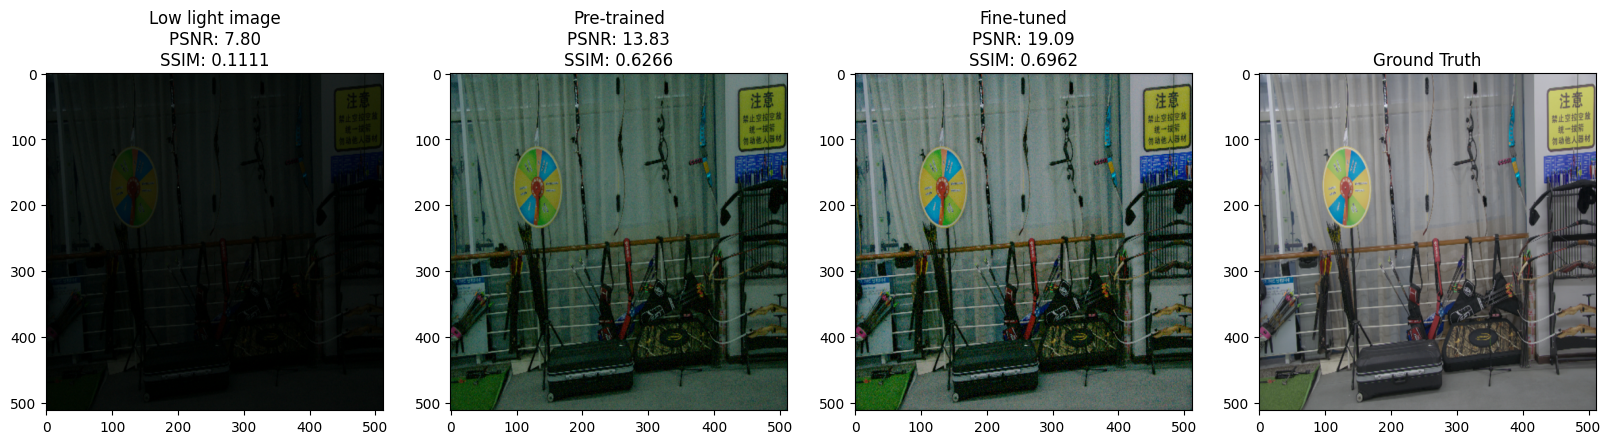

Processing image 00702...


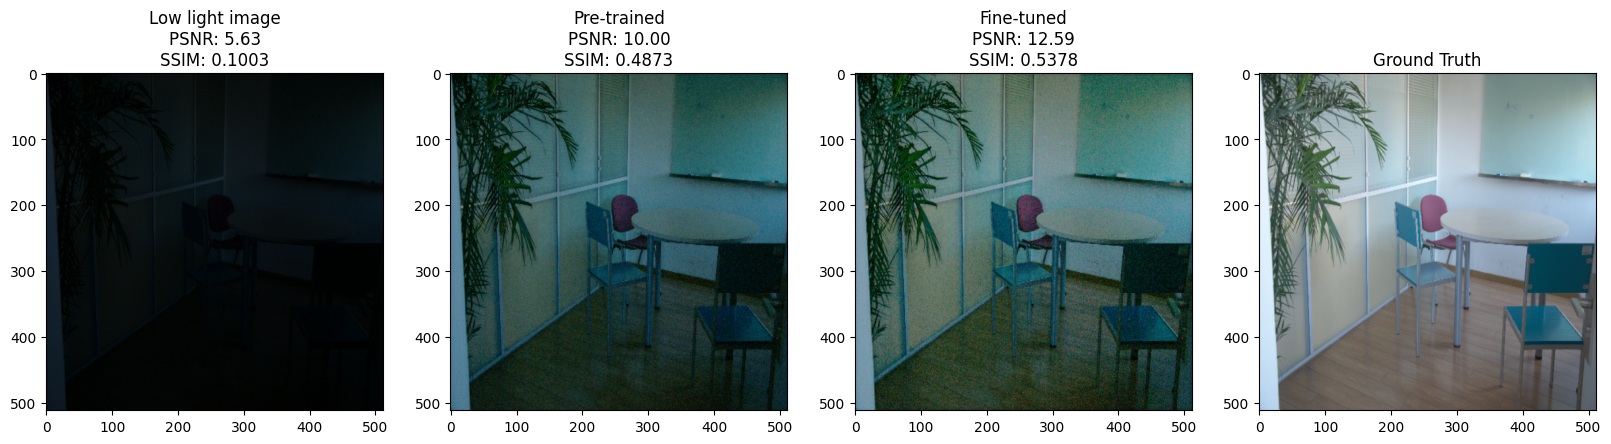

Processing image 00719...


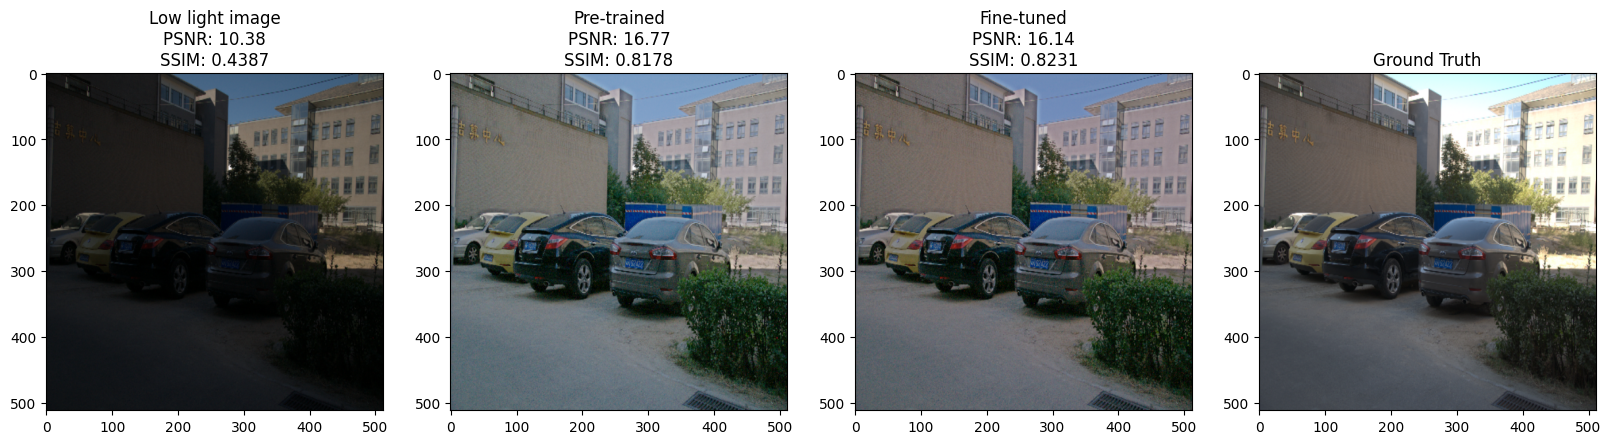

Processing image 00782...


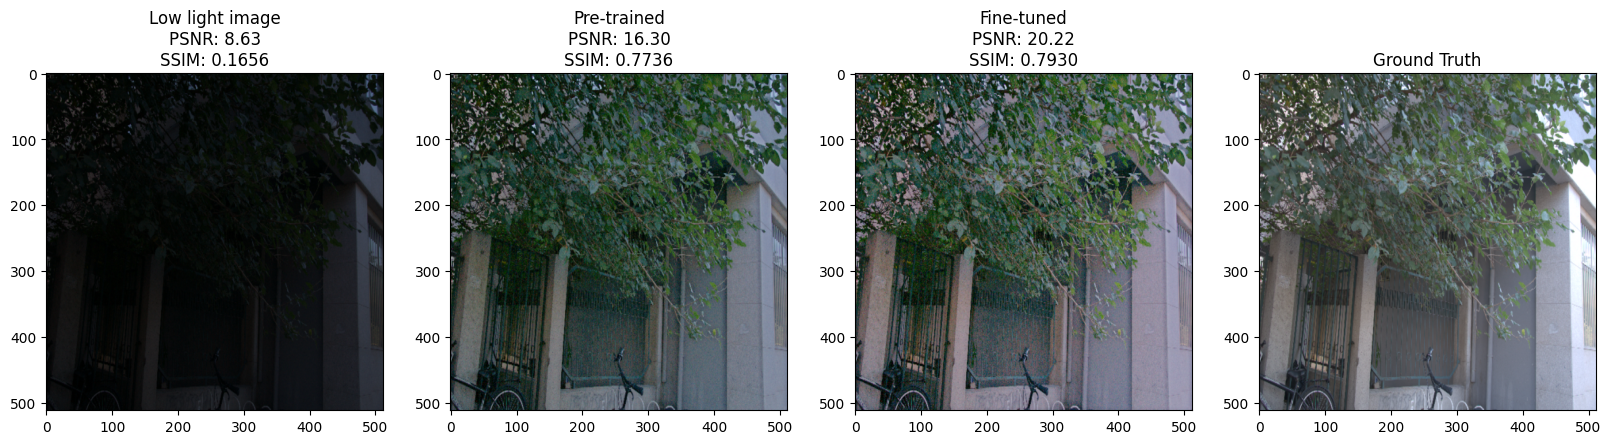

Processing image 00743...


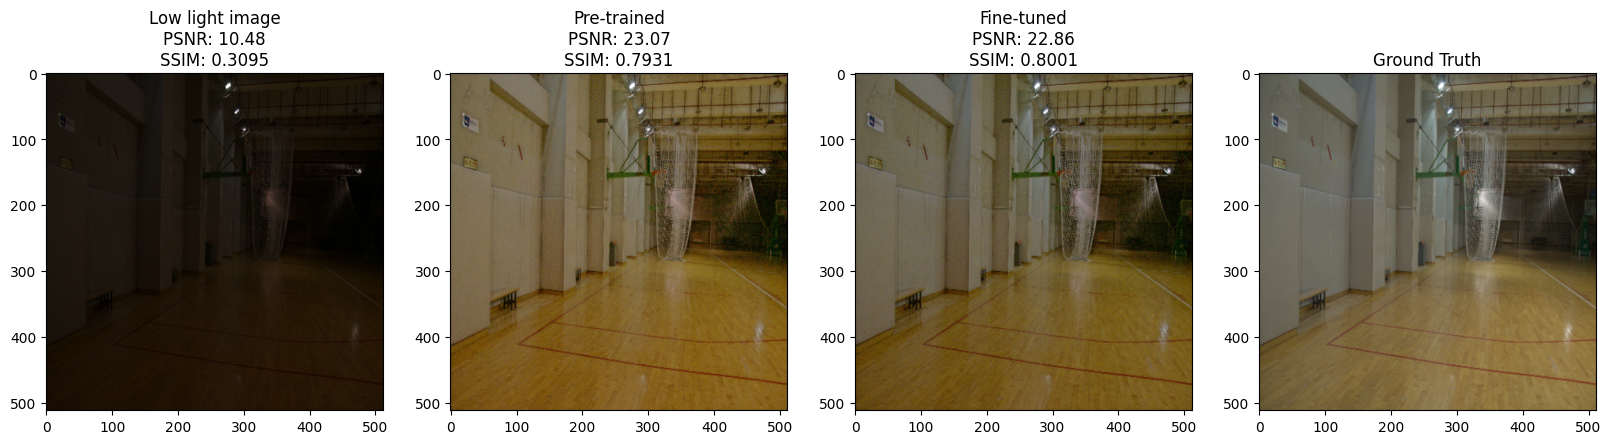

In [8]:
img_ids = ['00692', '00702', '00719', '00782', '00743']
results = []

DCE_net_pretrained = model.enhance_net_nopool().to(device)
DCE_net_pretrained.load_state_dict(torch.load(PRETRAINED_WEIGHTS, map_location=device))
DCE_net_pretrained.eval()

for idx in img_ids:
    print(f"Processing image {idx}...")
    img_lowlight = load_image(os.path.join(LOW_TEST_PATH, f'low{idx}.png'))
    reference_img = load_image(os.path.join(NORMAL_TEST_PATH, f'normal{idx}.png'))

    # Metrics for low light image
    psnr_lowlight, ssim_lowlight = compute_metrics(img_lowlight, reference_img)
    
    # Pre-trained Model output
    enhanced_img_pretrained = get_enhanced_image(DCE_net_pretrained, img_lowlight)
    psnr_pt, ssim_pt = compute_metrics(enhanced_img_pretrained, reference_img)
    
    # Fine-tuned Model ouptut
    DCE_net_finetuned = fine_tune_model_for_img(img_lowlight, PRETRAINED_WEIGHTS, num_epochs=50, mean_val = 0.4, tv_weight = 100, col_weight = 4, exp_weight=8)
    enhanced_img_ft = get_enhanced_image(DCE_net_finetuned, img_lowlight)
    psnr_ft, ssim_ft = compute_metrics(enhanced_img_ft, reference_img)
    
    results.append({
        'idx': idx,
        'psnr_low': psnr_lowlight, 'ssim_low': ssim_lowlight,
        'psnr_pre': psnr_pt, 'ssim_pre': ssim_pt,
        'psnr_ft': psnr_ft, 'ssim_ft': ssim_ft
    })
    
    # Plot
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes[0].imshow(img_lowlight.squeeze(0).permute(1, 2, 0).cpu().numpy()); axes[0].set_title(f"Low light image\nPSNR: {psnr_lowlight:.2f}\nSSIM: {ssim_lowlight:.4f}")
    axes[1].imshow(enhanced_img_pretrained.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()); axes[1].set_title(f"Pre-trained\nPSNR: {psnr_pt:.2f}\nSSIM: {ssim_pt:.4f}")
    axes[2].imshow(enhanced_img_ft.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()); axes[2].set_title(f"Fine-tuned\nPSNR: {psnr_ft:.2f}\nSSIM: {ssim_ft:.4f}")
    axes[3].imshow(reference_img.squeeze(0).permute(1, 2, 0).cpu().numpy()); axes[3].set_title("Ground Truth")
    plt.show()

In [13]:
print("Image | PSNR (Low) | SSIM (Low) | PSNR (Pre) | SSIM (Pre) | PSNR (FT) | SSIM (FT)")
print("------|-------|------|------|------|------|------")
for result in results:
    print(f"{result['idx']} | {result['psnr_low']:.2f} | {result['ssim_low']:.4f} | {result['psnr_pre']:.2f} | {result['ssim_pre']:.4f} | {result['psnr_ft']:.2f} | {result['ssim_ft']:.4f}")

Image | PSNR (Low) | SSIM (Low) | PSNR (Pre) | SSIM (Pre) | PSNR (FT) | SSIM (FT)
------|-------|------|------|------|------|------
00692 | 7.80 | 0.1111 | 13.83 | 0.6266 | 19.09 | 0.6962
00702 | 5.63 | 0.1003 | 10.00 | 0.4873 | 12.59 | 0.5378
00719 | 10.38 | 0.4387 | 16.77 | 0.8178 | 16.14 | 0.8231
00782 | 8.63 | 0.1656 | 16.30 | 0.7736 | 20.22 | 0.7930
00743 | 10.48 | 0.3095 | 23.07 | 0.7931 | 22.86 | 0.8001


In [ ]:
# DCE_net_finetuned = fine_tune_model_for_img(img_lowlight, PRETRAINED_WEIGHTS, num_epochs=50, mean_val = 0.4, tv_weight = 100, col_weight = 4, exp_weight=8)

# print("Image ID | PSNR (Pre-trained) | SSIM (Pre-trained) | PSNR (Fine-Tuned) | SSIM (Fine-Tuned)")
# print("------|-------|------|------|------")
# for r in results:
#     print(f"{r['idx']} | {r['psnr_pre']:.2f} | {r['ssim_pre']:.4f} | {r['psnr_ft']:.2f} | {r['ssim_ft']:.4f}")

Image ID | PSNR (Pre-trained) | SSIM (Pre-trained) | PSNR (Fine-Tuned) | SSIM (Fine-Tuned)
------|-------|------|------|------
00692 | 13.83 | 0.6266 | 19.09 | 0.6962
00702 | 10.00 | 0.4873 | 12.59 | 0.5378
00719 | 16.77 | 0.8178 | 16.14 | 0.8231
00782 | 16.30 | 0.7736 | 20.22 | 0.7930
00743 | 23.07 | 0.7931 | 22.86 | 0.8001


In [ ]:
# DCE_net_finetuned = fine_tune_model_for_img(img_lowlight, PRETRAINED_WEIGHTS, num_epochs=50, mean_val = 0.3, tv_weight = 100, )

# print("Image ID | PSNR (Pre-trained) | SSIM (Pre-trained) | PSNR (Fine-Tuned) | SSIM (Fine-Tuned)")
# print("------|-------|------|------|------")
# for r in results:
#     print(f"{r['idx']} | {r['psnr_pre']:.2f} | {r['ssim_pre']:.4f} | {r['psnr_ft']:.2f} | {r['ssim_ft']:.4f}")

Image ID | PSNR (Pre-trained) | SSIM (Pre-trained) | PSNR (Fine-Tuned) | SSIM (Fine-Tuned)
------|-------|------|------|------
00692 | 13.83 | 0.6266 | 14.78 | 0.6547
00702 | 10.00 | 0.4873 | 10.15 | 0.4910
00719 | 16.77 | 0.8178 | 15.58 | 0.8471
00782 | 16.30 | 0.7736 | 15.83 | 0.7672
00743 | 23.07 | 0.7931 | 18.17 | 0.7756


In [ ]:
# DCE_net_finetuned = fine_tune_model_for_img(img_lowlight, PRETRAINED_WEIGHTS, num_epochs=50, mean_val = 0.5, tv_weight = 100, )

# print("Image ID | PSNR (Pre-trained) | SSIM (Pre-trained) | PSNR (Fine-Tuned) | SSIM (Fine-Tuned)")
# print("------|-------|------|------|------")
# for r in results:
#     print(f"{r['idx']} | {r['psnr_pre']:.2f} | {r['ssim_pre']:.4f} | {r['psnr_ft']:.2f} | {r['ssim_ft']:.4f}")

Image ID | PSNR (Pre-trained) | SSIM (Pre-trained) | PSNR (Fine-Tuned) | SSIM (Fine-Tuned)
------|-------|------|------|------
00692 | 13.83 | 0.6266 | 21.48 | 0.6860
00702 | 10.00 | 0.4873 | 16.28 | 0.5500
00719 | 16.77 | 0.8178 | 14.78 | 0.7502
00782 | 16.30 | 0.7736 | 19.94 | 0.7551
00743 | 23.07 | 0.7931 | 21.85 | 0.7631


In [ ]:
# DCE_net_finetuned = fine_tune_model_for_img(img_lowlight, PRETRAINED_WEIGHTS, num_epochs=50, mean_val = 0.4, tv_weight = 100, )

# print("Image ID | PSNR (Pre-trained) | SSIM (Pre-trained) | PSNR (Fine-Tuned) | SSIM (Fine-Tuned)")
# print("------|-------|------|------|------")
# for r in results:
#     print(f"{r['idx']} | {r['psnr_pre']:.2f} | {r['ssim_pre']:.4f} | {r['psnr_ft']:.2f} | {r['ssim_ft']:.4f}")

Image ID | PSNR (Pre-trained) | SSIM (Pre-trained) | PSNR (Fine-Tuned) | SSIM (Fine-Tuned)
------|-------|------|------|------
00692 | 13.83 | 0.6266 | 19.17 | 0.6963
00702 | 10.00 | 0.4873 | 12.60 | 0.5372
00719 | 16.77 | 0.8178 | 15.91 | 0.8151
00782 | 16.30 | 0.7736 | 20.24 | 0.7890
00743 | 23.07 | 0.7931 | 22.99 | 0.7996


## Test on Captured Images

Processing image IMG_4320.jpg...


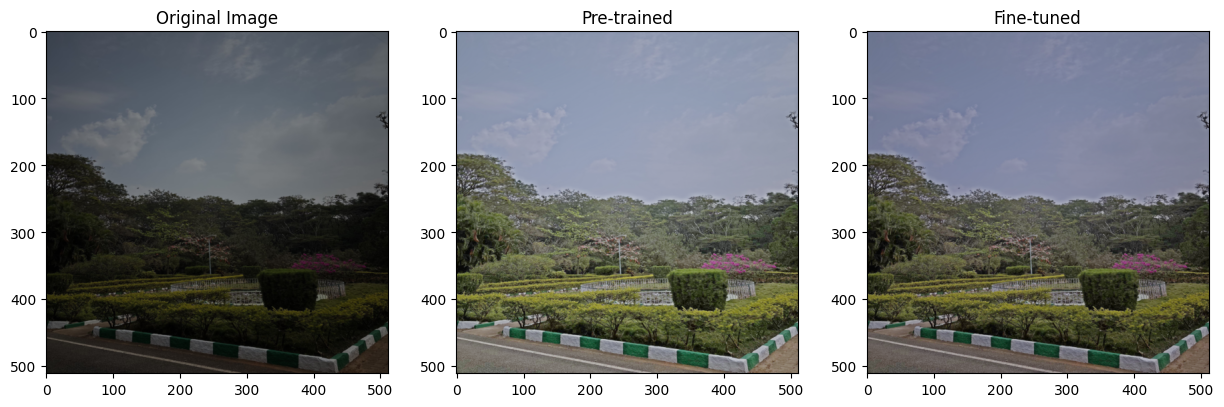

Processing image IMG_7132.jpg...


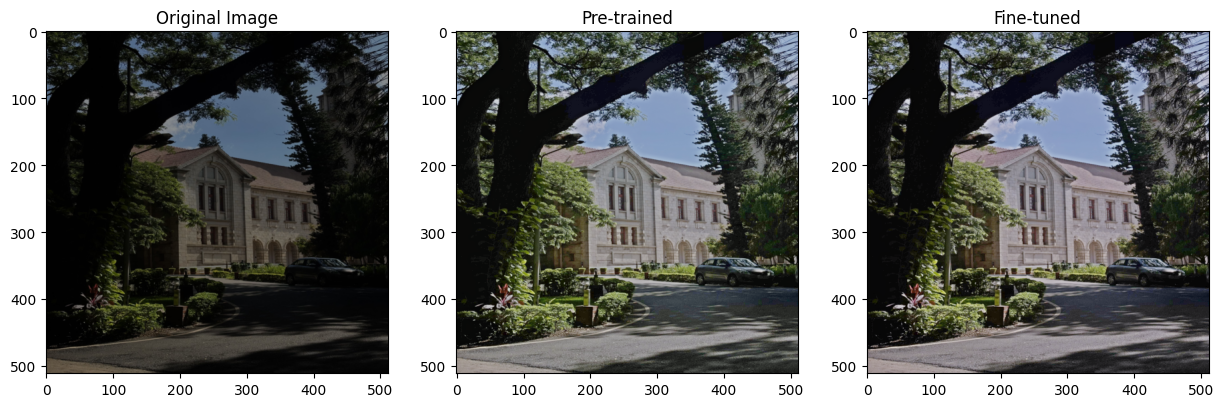

Processing image IMG_8633.jpg...


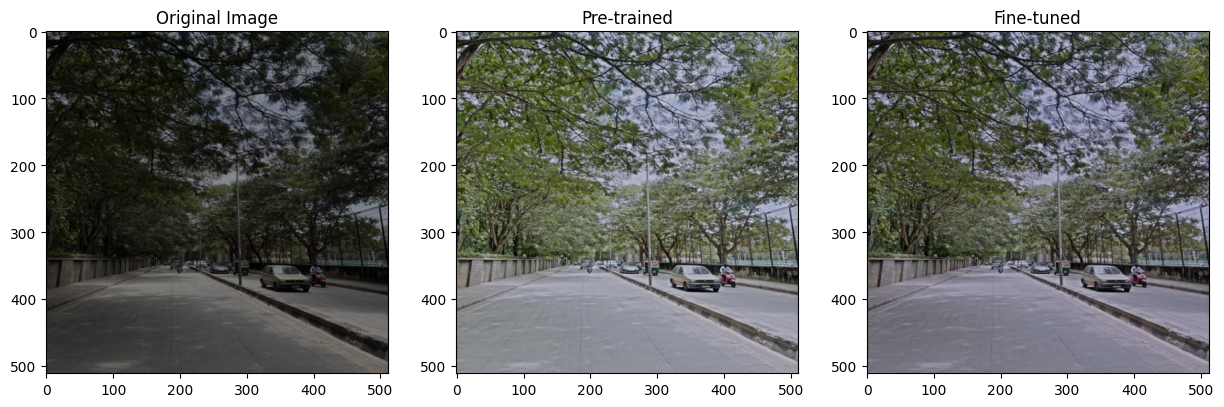

Processing image IMG_8700.jpeg...


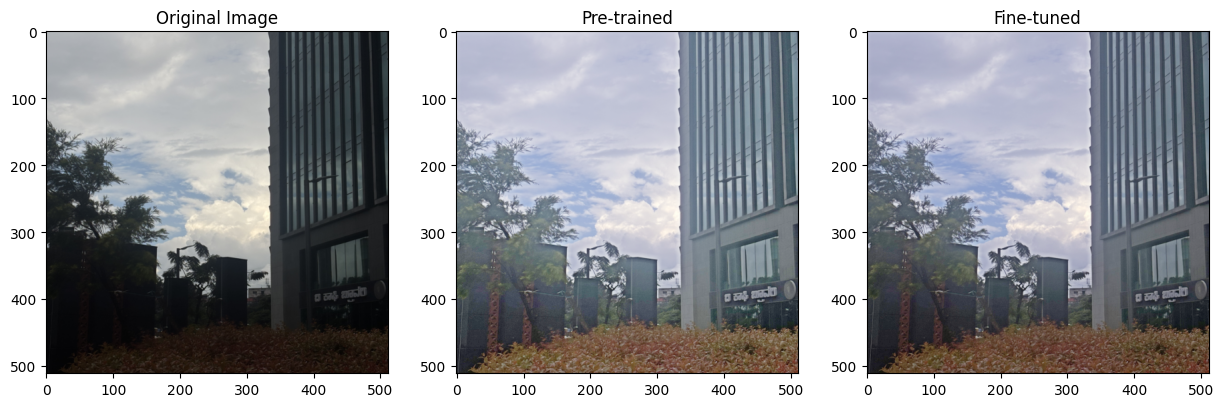

In [14]:
captured_images = ['IMG_4320.jpg', 'IMG_7132.jpg', 'IMG_8633.jpg', 'IMG_8700.jpeg']
for file_name in captured_images:
    print(f"Processing image {file_name}...")
    img_lowlight = load_image(os.path.join(CAPTURED_IMAGE_PATH, f'{file_name}'))
    enhanced_img_pretrained = get_enhanced_image(DCE_net_pretrained, img_lowlight)

    # Fine-tuned Model ouptut
    DCE_net_finetuned = fine_tune_model_for_img(img_lowlight, PRETRAINED_WEIGHTS, num_epochs=50, mean_val = 0.4, tv_weight = 100, col_weight = 4, exp_weight=8)
    enhanced_img_ft = get_enhanced_image(DCE_net_finetuned, img_lowlight)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_lowlight.squeeze(0).permute(1, 2, 0).cpu().numpy()); axes[0].set_title("Original Image")
    axes[1].imshow(enhanced_img_pretrained.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()); axes[1].set_title("Pre-trained")
    axes[2].imshow(enhanced_img_ft.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()); axes[2].set_title("Fine-tuned")
    plt.show()